# 2.5 — When to hedge: bands, costs and frequency

> *"The perfect hedge is a hedge you re-balance continuously at zero cost. Neither half of that sentence
> exists."*

## The problem

The market-making books send us a new inventory number every few seconds. Three policies are on the
table:

* **Hedge every fill** — risk is always ~zero, and we pay half a spread plus impact on every lot, twice
  (once when the customer trades, once when we hedge). At 40 fills a day this is a lot of spread.
* **Hedge at the close** — one trade a day, minimal cost, but the book runs naked all day.
* **Hedge when a band is breached** — do nothing while $|{\text{net position}}| \le B$, trade back to
  zero when it is exceeded.

Equation (2.4) already told us small positions should not be hedged at all when costs are considered.
This chapter turns that into an operating rule with a number in it, $B$, derives how $B$ should scale,
and shows the **cost–variance frontier** that the desk head must pick a point on.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.market_data import simulate_mm_inventory, simulate_hub_history, liquidity_for, month_bucket
from gashedge.hedging import band_hedging, band_sweep, execution_cost
from gashedge.plotting import plot_series
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch2.5")
log.info("Environment ready")

2026-09-13 16:47:06.477 | INFO    | ch2.5 | Environment ready


## 1. Setting up the experiment

Daily inventory from the MM simulator, front-month prices, and the front-month liquidity from Chapter
1.3. `band_hedging` applies the rule "if $|I_t + \text{hedge}_t| > B$, trade to flat" and charges
execution cost via equation (1.8). (Daily granularity is a simplification — intraday the same logic
applies with more steps.)

In [2]:
N = 500
inv = simulate_mm_inventory(n_days=N, fills_per_day=40, lot_std=2.0, seed=5)
px = simulate_hub_history(n_days=N, start=date(2025, 1, 2), ttf0=35.0, seed=8).TTF
px.index = inv.index
liq = liquidity_for(month_bucket(1), "TTF")
LOT_MWH = 730
bands = [0, 5, 10, 20, 35, 50, 75, 100, 150, 250, 10**9]
sweep = band_sweep(inv, px, LOT_MWH, bands, liq["bid_ask"], liq["depth_lots"])
sweep["band_label"] = sweep.band_lots.replace({10**9: "never hedge"}).astype(str)
sweep["annual_cost"] = sweep.total_cost * 250 / N
sweep["annual_pnl_std"] = sweep.pnl_std * np.sqrt(250)
log.info("Hedge every day: cost %.0f EUR/yr, P&L std %.0f/day. Never: cost 0, std %.0f/day",
         sweep.annual_cost.iloc[0], sweep.pnl_std.iloc[0], sweep.pnl_std.iloc[-1])
sweep[["band_label", "n_trades", "lots_traded", "annual_cost", "pnl_std", "worst_day"]].round(0)

2026-09-13 16:47:06.484 | INFO    | gashedge.market_data | Simulated MM inventory: final 79 lots, max |inv| 121 lots


2026-09-13 16:47:06.488 | INFO    | gashedge.market_data | Simulated 500 days of hub history (crisis=False); TTF range 21.1-58.4


2026-09-13 16:47:06.496 | INFO    | ch2.5 | Hedge every day: cost 14970 EUR/yr, P&L std 54/day. Never: cost 0, std 50413/day


,band_label,n_trades,lots_traded,annual_cost,pnl_std,worst_day
0,0,484,5081.0,14970.0,54.0,-292.0
1,5,334,4645.0,13948.0,2410.0,-15188.0
2,10,221,4019.0,12531.0,5938.0,-42180.0
3,20,102,2829.0,9542.0,10900.0,-94269.0
4,35,36,1554.0,5805.0,18710.0,-123589.0
5,50,18,997.0,3968.0,26193.0,-159893.0
6,75,9,736.0,3269.0,32846.0,-135197.0
7,100,7,744.0,3574.0,48137.0,-244739.0
8,150,0,0.0,0.0,50413.0,-237688.0
9,250,0,0.0,0.0,50413.0,-237688.0


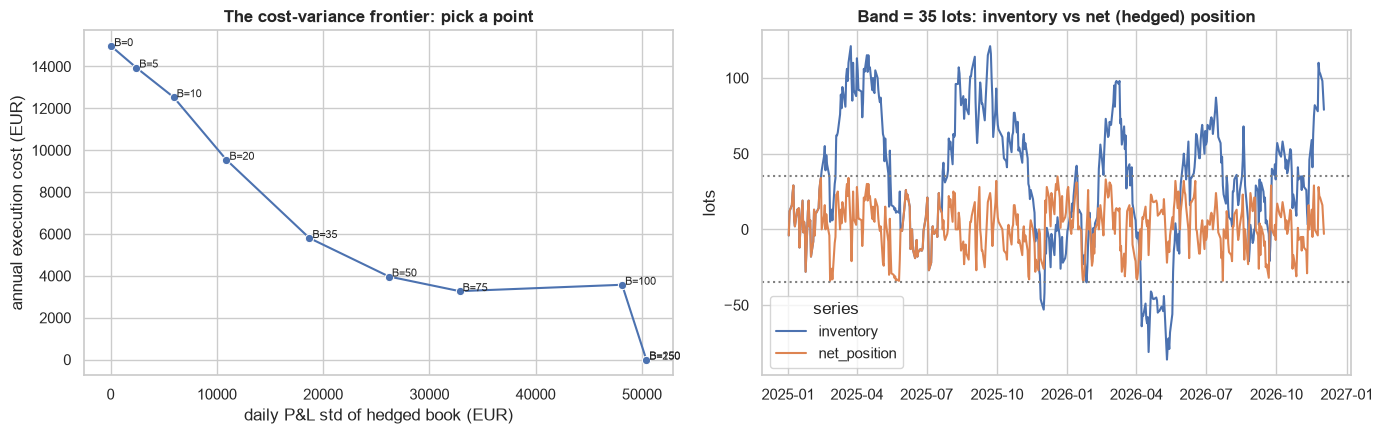

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sub = sweep[sweep.band_lots < 10**9]
sns.lineplot(data=sub, x="pnl_std", y="annual_cost", marker="o", ax=axes[0])
for r in sub.itertuples():
    axes[0].text(r.pnl_std, r.annual_cost, f" B={int(r.band_lots)}", fontsize=8)
axes[0].set_xlabel("daily P&L std of hedged book (EUR)"); axes[0].set_ylabel("annual execution cost (EUR)")
axes[0].set_title("The cost-variance frontier: pick a point")
ex = band_hedging(inv, px, LOT_MWH, 35, liq["bid_ask"], liq["depth_lots"])
plot_series(ex[["inventory", "net_position"]], title="Band = 35 lots: inventory vs net (hedged) position", ylabel="lots", ax=axes[1])
axes[1].axhline(35, color="0.5", ls=":"); axes[1].axhline(-35, color="0.5", ls=":")
plt.tight_layout()

The frontier is steep at the left: going from "hedge daily" to a small band cuts cost dramatically for a
tiny increase in risk. It flattens to the right: wide bands save little more cost and add a lot of
variance. The knee of the curve is where desks live.

## 2. Deriving the shape: why the optimal band scales as a cube root

Let inventory arrive as a random walk with daily standard deviation $\sigma_I$ lots (from the fills), and
let price have daily volatility $\sigma_P$ EUR/MWh. With a band $B$:

* **Risk.** The net position wanders uniformly inside $[-B, B]$ (approximately), so its variance is
  $B^2/3$. Daily P&L variance from position risk is therefore about
  $\text{Var}(\Pi) \approx \tfrac{B^2}{3} H^2 \sigma_P^2$.
  Risk charge per day: $\tfrac{\lambda}{2}\cdot\tfrac{B^2}{3}H^2\sigma_P^2$.
* **Cost.** A random walk with step $\sigma_I$ hits a band at distance $B$ roughly every $B^2/\sigma_I^2$
  days, and each hit trades $\approx B$ lots at proportional cost $c$ EUR per lot. Cost per day
  $\approx cB \cdot \sigma_I^2/B^2 = c\,\sigma_I^2 / B$.

Total daily cost $J(B) = a B^2 + b/B$ with $a = \lambda H^2\sigma_P^2/6$ and $b = c\sigma_I^2$.
Setting $J'(B) = 2aB - b/B^2 = 0$:

$$
B^{*} = \left(\frac{b}{2a}\right)^{1/3} = \left(\frac{3\,c\,\sigma_I^2}{\lambda H^2 \sigma_P^2}\right)^{1/3}
\tag{2.8}
$$

The cube root is the important part, and it is the same law that governs option re-hedging bands with
transaction costs (Whalley & Wilmott, 1997): **the optimal band is very insensitive to the inputs**. Double
the cost, the band grows 26 %; double the volatility, it shrinks 37 %. You do not need $\lambda$ to three
decimals — you need the *order of magnitude* right, and then the frontier does the rest.

In [4]:
def optimal_band(c_per_lot, sigma_inv_lots, lam, lot_mwh, sigma_price):
    return (3 * c_per_lot * sigma_inv_lots**2 / (lam * lot_mwh**2 * sigma_price**2)) ** (1 / 3)

sigma_I = inv.diff().std()                                   # lots per day
sigma_P = px.diff().std()                                    # EUR/MWh per day
c_lot = execution_cost(20, liq["bid_ask"], LOT_MWH, liq["depth_lots"]) / 20   # EUR per lot at a typical 20-lot clip
lams = [1e-7, 3e-7, 1e-6, 3e-6, 1e-5]
tbl = pd.DataFrame({"lambda": lams})
tbl["B_star_lots"] = [optimal_band(c_lot, sigma_I, l, LOT_MWH, sigma_P) for l in lams]
log.info("sigma_I=%.1f lots/day, sigma_P=%.2f EUR/MWh/day, c=%.1f EUR/lot -> B* ranges %.0f..%.0f lots across a 100x range of lambda",
         sigma_I, sigma_P, c_lot, tbl.B_star_lots.max(), tbl.B_star_lots.min())
tbl.round(1)

2026-09-13 16:47:06.712 | INFO    | ch2.5 | sigma_I=12.9 lots/day, sigma_P=1.65 EUR/MWh/day, c=6.2 EUR/lot -> B* ranges 28..6 lots across a 100x range of lambda


,lambda,B_star_lots
0,0.0,27.8
1,0.0,19.3
2,0.0,12.9
3,0.0,8.9
4,0.0,6.0


A hundred-fold change in risk aversion moves the optimal band by less than a factor of five. That
robustness is why band hedging is universal: it is hard to get badly wrong.

## 3. Refinements that practitioners add

* **Asymmetric bands** when the book has a structural skew (customers net buyers in autumn): hedge
  earlier on the side you expect to keep growing.
* **Hedge to the band edge, not to zero** (a "reflecting" policy). It trades less than resetting to zero
  and is close to optimal when costs are proportional; resetting to zero is better when there is a fixed
  cost per trade. Try `target=` in `band_hedging`.
* **Time-of-day bands**: wider when liquidity is thin (lunch, after the close of the physical market),
  tighter into the settlement window when the desk's marks are set.
* **Vol-scaled bands**: equation (2.8) says $B^* \propto \sigma_P^{-2/3}$. Feed a short-horizon vol
  estimate (EWMA) and let the band tighten automatically when the market gets loud — it is what a good
  trader does by instinct.
* **Never hedge the *forecast***: hedging in anticipation of flow is a prop position. The band reacts to
  realised inventory only.

## 4. The market-maker's other lever (for context)

Our job is the hedging side, but it is worth knowing that the *quoting* side has its own inventory
control: **skewing quotes**. A book that is long shades both bid and offer down so that it is more likely
to sell than to buy; Avellaneda & Stoikov (2008) derive the optimal skew as roughly $\gamma\sigma^2 I (T-t)$
— linear in inventory. Skewing *attracts* the offsetting flow (and earns spread on it); hedging *buys*
the offset (and pays spread). A well-run franchise uses both: skew inside the band, hedge at the band.

## 5. Where this leaves us

We now have a complete *mechanical* hedging policy: choose the liquid proxy (2.2), size it by ratio
(2.3), roll or migrate it (2.4), and trigger it by a band that scales as a cube root of cost over
variance (2.5).

**Pitfall that leads to the next chapter:** we have been working one exposure at a time. The real book
has PEG and TTF, months and seasons, dozens of tenors — and their residuals partly *offset each other*.
A hedging engine must aggregate first and hedge the net. Chapter 2.6 assembles the pipeline; Module 3
then supplies the statistics it needs.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** Inventory arrives with $\sigma_I = 12$ lots/day, front-month price volatility is $\sigma_P = 1.2$ EUR/MWh/day, lot size 730 MWh, execution cost $c = 8$ EUR/lot, and $\lambda = 10^{-6}$ per EUR. Compute $B^*$ from (2.8). Then recompute with $\lambda = 10^{-5}$.

<details><summary><i>Answer 1</i></summary>

$B^* = \left(\dfrac{3 \times 8 \times 144}{10^{-6} \times 730^2 \times 1.44}\right)^{1/3} = \left(\dfrac{3456}{0.7674}\right)^{1/3} = (4503)^{1/3} \approx \mathbf{16.5\ lots}$. With $\lambda = 10^{-5}$: $(450.3)^{1/3} \approx \mathbf{7.7\ lots}$. Ten times the risk aversion, less than half the band — the cube-root damping.

</details>

**Q2.** Explain why 'hedge every fill' is *not* the zero-risk policy it appears to be, and identify two costs it incurs beyond the bid–ask spread.

<details><summary><i>Answer 2</i></summary>

Residual risk remains between the customer fill and the hedge fill (latency, partial fills, the hedge instrument gapping), and — more importantly — every hedge is itself a *signal*: a stream of one-directional small orders reveals the desk's flow to the market, inviting adverse selection (others fade or front-run the hedges). Costs beyond the spread: (1) **market impact** from continuous one-sided pressure, which by the square-root law is *less* when orders are batched (cost of $n$ lots at once $\propto n^{3/2}$ vs. $n$ separate 1-lot orders each paying the same fixed half-spread — for small clips the half-spread dominates and batching wins; for large clips impact dominates and splitting wins, the band picks the balance); (2) **operational/fee cost** — exchange and clearing fees per lot, and the engineering cost of a low-latency hedger that has to be right every time.

</details>

**Q3.** Suppose the desk wants the hedged book's daily P&L standard deviation below €30k. From the frontier table in this notebook (or by re-running with your own seed), what band achieves that, and what does it cost per year? How does the answer change if the front-month bid–ask doubles?

<details><summary><i>Answer 3</i></summary>

Read across the sweep for the largest band with `pnl_std` < 30,000 and take its `annual_cost`; with the default seed this lands around a band of a few tens of lots (the exact value depends on the seed — that is the point of running it). If the bid–ask doubles, $c$ doubles: by (2.8) the *optimal* band grows by $2^{1/3} = 1.26\times$, but the *constraint-satisfying* band does not change (risk does not depend on $c$) — so you keep the same band and pay roughly double the cost. A risk-limit formulation and a cost-minimising formulation react differently to the same shock; be clear which one your desk is running.

</details>

**Q4.** A band policy 'hedge back to zero when $|I| > B$' and a policy 'hedge back to $\pm B$ (the edge)' both use the same $B$. Which trades more often, which trades more lots in total, and which is preferable when there is a fixed ticket cost per trade?

<details><summary><i>Answer 4</i></summary>

Hedging to the **edge** trades *more often* (after each hedge you are still at the boundary, so the next small move re-triggers) but in *smaller clips*; hedging to **zero** trades *less often* in larger clips (≈ $B$ lots each). Total lots traded are similar to first order (both must offset the same cumulative inventory drift), so with purely proportional costs the two are close, with the edge policy slightly better on variance for the same cost. With a **fixed cost per ticket**, frequent small trades are penalised, so **hedge to zero** (or to a point well inside the band) is preferable — the classic result from inventory theory and from option-hedging with fixed costs.

</details>


---
◀ [Previous](04_stack_and_roll.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](06_proxy_hedging_pipeline.ipynb)